In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("Amazon Store Sales Data.xlsx")
df.head()


,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,0,Online
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,0,Online
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,0,Cards
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,0,Online
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,0,Online


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID+O6G3A1:R6  5901 non-null   int64         
 1   Order ID          5901 non-null   object        
 2   Order Date        5901 non-null   datetime64[ns]
 3   Ship Date         5901 non-null   datetime64[ns]
 4   Ship Mode         5901 non-null   object        
 5   Customer ID       5901 non-null   object        
 6   Customer Name     5901 non-null   object        
 7   Segment           5901 non-null   object        
 8   Country           5901 non-null   object        
 9   City              5901 non-null   object        
 10  State             5901 non-null   object        
 11  Region            5901 non-null   object        
 12  Product ID        5901 non-null   object        
 13  Category          5901 non-null   object        
 14  Sub-Category      5901 n

In [5]:
df.isnull().sum()

Row ID+O6G3A1:R6    0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Returns             0
Payment Mode        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#checking for valid order and ship dates
df['valid'] = (
    df['Order Date'].notna() &
    df['Ship Date'].notna() &
    (df['Ship Date'] >= df['Order Date'])
)

print(df)


      Row ID+O6G3A1:R6        Order ID Order Date  ... Returns Payment Mode valid
0                 4918  CA-2019-160304 2019-01-01  ...       0       Online  True
1                 4919  CA-2019-160304 2019-01-02  ...       0       Online  True
2                 4920  CA-2019-160304 2019-01-02  ...       0        Cards  True
3                 3074  CA-2019-125206 2019-01-03  ...       0       Online  True
4                 8604  US-2019-116365 2019-01-03  ...       0       Online  True
...                ...             ...        ...  ...     ...          ...   ...
5896               907  CA-2020-143259 2020-12-30  ...       0          COD  True
5897              1297  CA-2020-115427 2020-12-30  ...       1       Online  True
5898              5092  CA-2020-156720 2020-12-30  ...       0       Online  True
5899               909  CA-2020-143259 2020-12-30  ...       0          COD  True
5900              5093  CA-2020-151450 2020-12-31  ...       0          COD  True

[5901 rows x 22

In [8]:
df.rename(columns={"Row ID+O6G3A1:R6":"Row_ID"}, inplace=True)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

sales trend analysis

In [10]:
# monthly sales
df["Month"] = df["Order Date"].dt.month
monthly_orders = df.groupby("Month")["Sales"].sum()

# yearly sales 
df["Year"] = df["Order Date"].dt.year
yearly_orders = df.groupby("Year")["Sales"].sum()

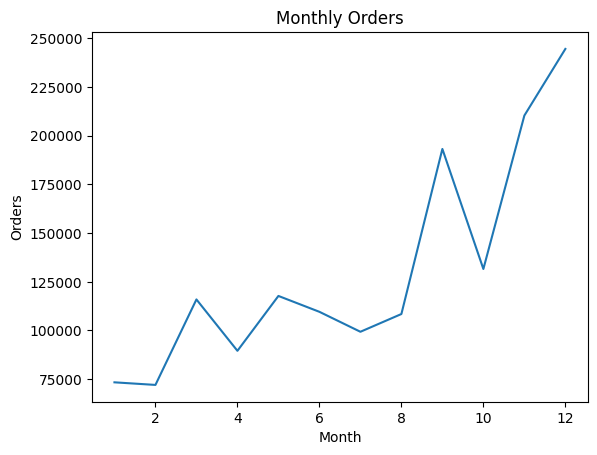

In [11]:

plt.plot(monthly_orders.index, monthly_orders.values)
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()


there is a seasonal spike in the sales 

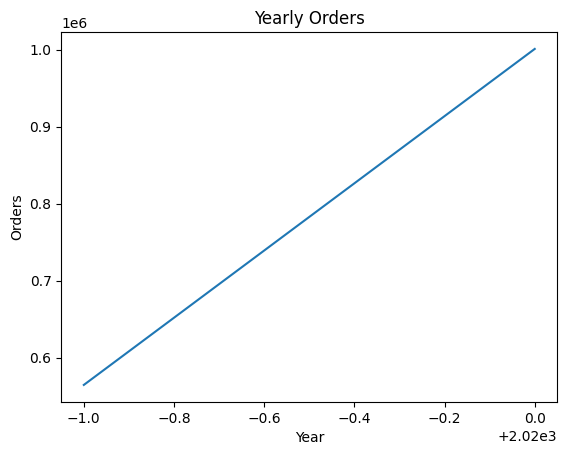

In [12]:

plt.plot(yearly_orders.index, yearly_orders.values)
plt.title("Yearly Orders")
plt.xlabel("Year")
plt.ylabel("Orders")
plt.show()


<Axes: xlabel='Sub-Category', ylabel='Month'>

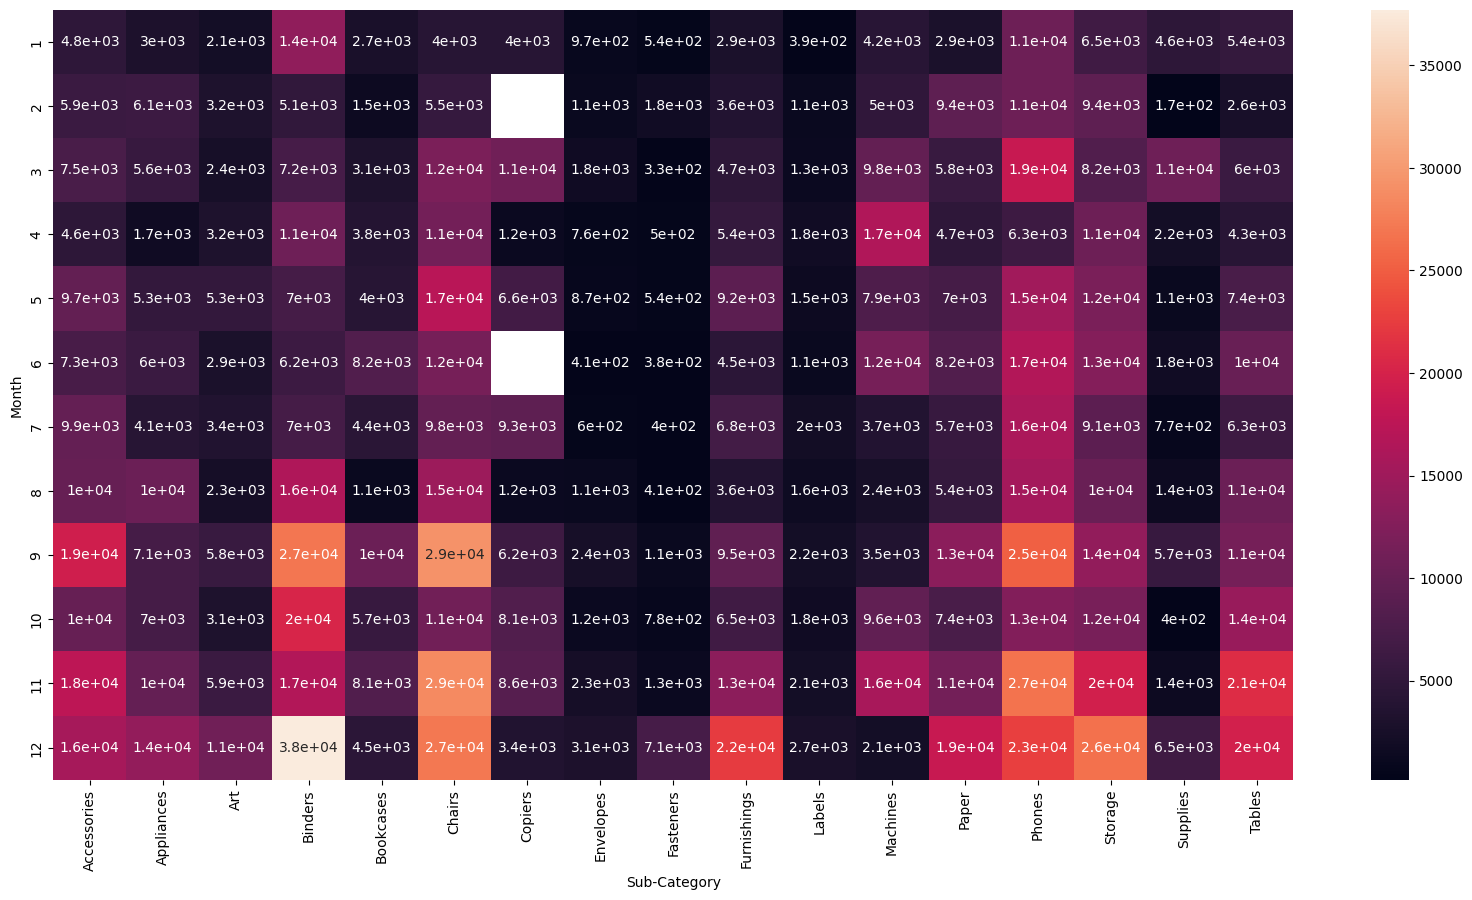

In [13]:
pivot = df.pivot_table(
    values='Sales',
    index='Month',
    columns='Sub-Category',
    aggfunc='sum'
)
plt.figure(figsize=(20, 10))
sns.heatmap(pivot, annot=True)

1.there is a strong seasonal trend seen in months 9,11,12 may be due to festive season this is present in categories such as: binders, chairs, phones,tables, furnishing

2.phone have high sales throughout the year (possibly a top selling commodity)

3.binders sales peak in last month may be due to bulk office/institutional purchases

4.some categories like envelopes, fastners, labels contribute less to business growth

5.white banks (in month 2 and 6) are possibly missing values or extremely high values



In [14]:
df[df['Sub-Category'] == 'Copiers']['Sales'].isnull().sum()

np.int64(0)

thus the white blocks in the heatmap are not missing values, i.e they are large values 

In [15]:
# Maximum value
df[df['Sub-Category']=='Copiers']['Sales'].max()

# Describe distribution
df[df['Sub-Category']=='Copiers']['Sales'].describe()

count      38.000000
mean     1571.994684
std      1342.572947
min        99.960000
25%       530.226000
50%      1002.482000
75%      2409.714000
max      5517.970000
Name: Sales, dtype: float64

confirms that there are very large values contributing to 

In [16]:
# detecting sales spikes
df['rolling_mean'] = df['Sales'].rolling(window=3).mean()
df['spike'] = df['Sales'] > (df['rolling_mean'] * 1.5)  # spike if 50% above average


In [17]:
df.columns

Index(['Row_ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'valid',
       'Month', 'Year', 'rolling_mean', 'spike'],
      dtype='object')

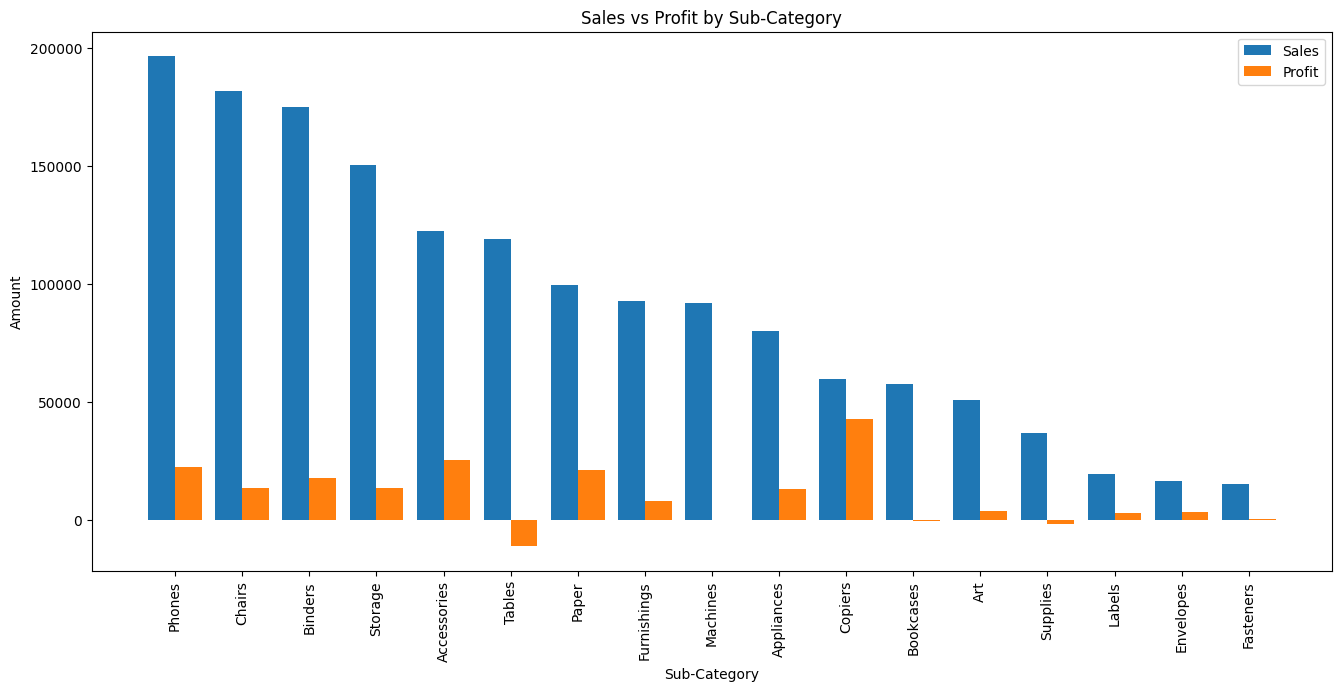

In [18]:
product_summary = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()

product_summary = product_summary.sort_values(by='Sales', ascending=False)

x = np.arange(len(product_summary))

width = 0.4

plt.figure(figsize=(16,7))

plt.bar(x - width/2, product_summary['Sales'], width, label='Sales')

plt.bar(x + width/2, product_summary['Profit'], width, label='Profit')

plt.xticks(x, product_summary['Sub-Category'], rotation=90)

plt.title("Sales vs Profit by Sub-Category")

plt.xlabel("Sub-Category")
plt.ylabel("Amount")

plt.legend()

plt.show()

products with high sales and low profit are worst: chairs,storage
products with low sales and high profit are best:copiers
tables are in loss

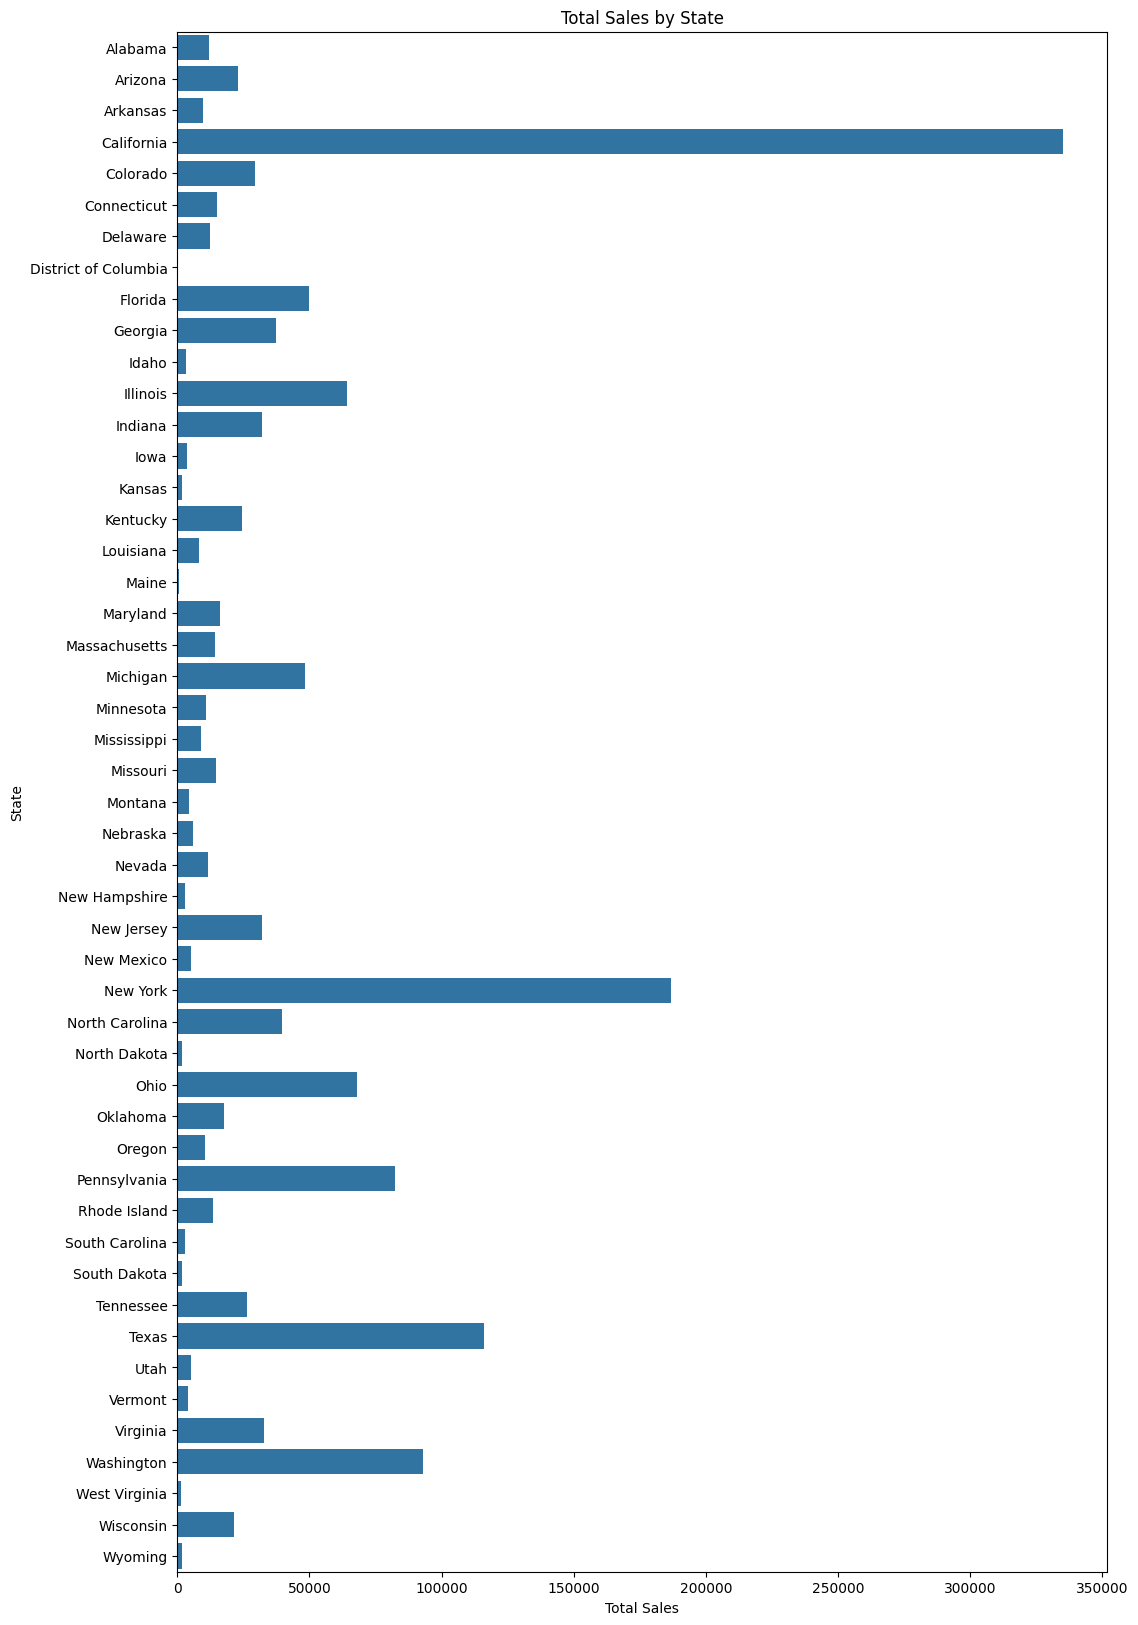

In [19]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

plt.figure(figsize=(12,20))

sns.barplot(
    y='State',
    x='Sales',
    data=state_sales
)

plt.title("Total Sales by State")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.show()

highest revenue states: california,new york,

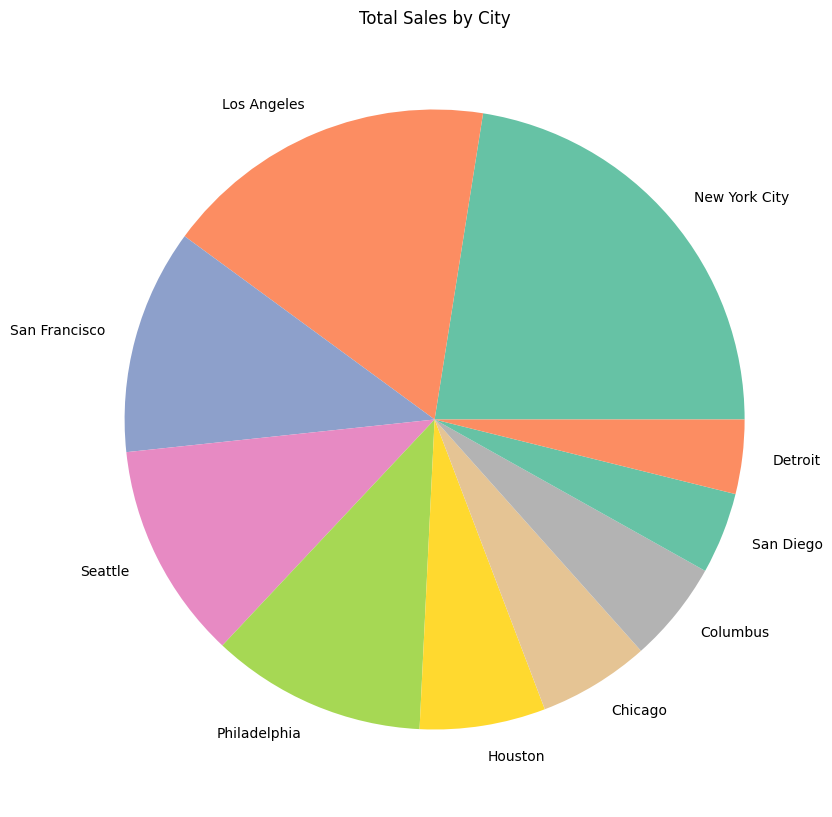

In [20]:
City_sales = df.groupby('City')['Sales'].sum().reset_index()
top_cities = City_sales.sort_values(by='Sales', ascending=False).head(10)
plt.figure(figsize=(10,20))

plt.pie(top_cities['Sales'], labels=top_cities['City'], colors=sns.color_palette("Set2"))


plt.title("Total Sales by City")


plt.show()

maximum sales can be seen in cities: los angeles, new york city,    San francisco, seattle and chicago

In [21]:
df.columns

Index(['Row_ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'valid',
       'Month', 'Year', 'rolling_mean', 'spike'],
      dtype='object')

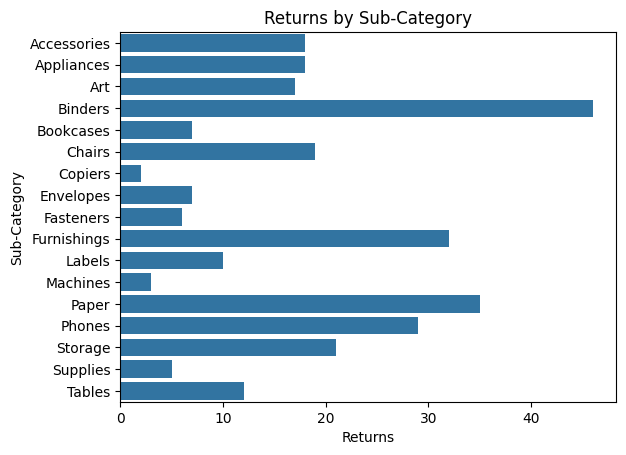

In [22]:
returns = df.groupby('Sub-Category')['Returns'].sum().reset_index()
sns.barplot( x='Returns', y='Sub-Category', data=returns ,errorbar=None)
plt.title("Returns by Sub-Category")
plt.xlabel("Returns")
plt.ylabel("Sub-Category")
plt.show()

coipiers have high sales and low returns whereas binders have highest return rate 

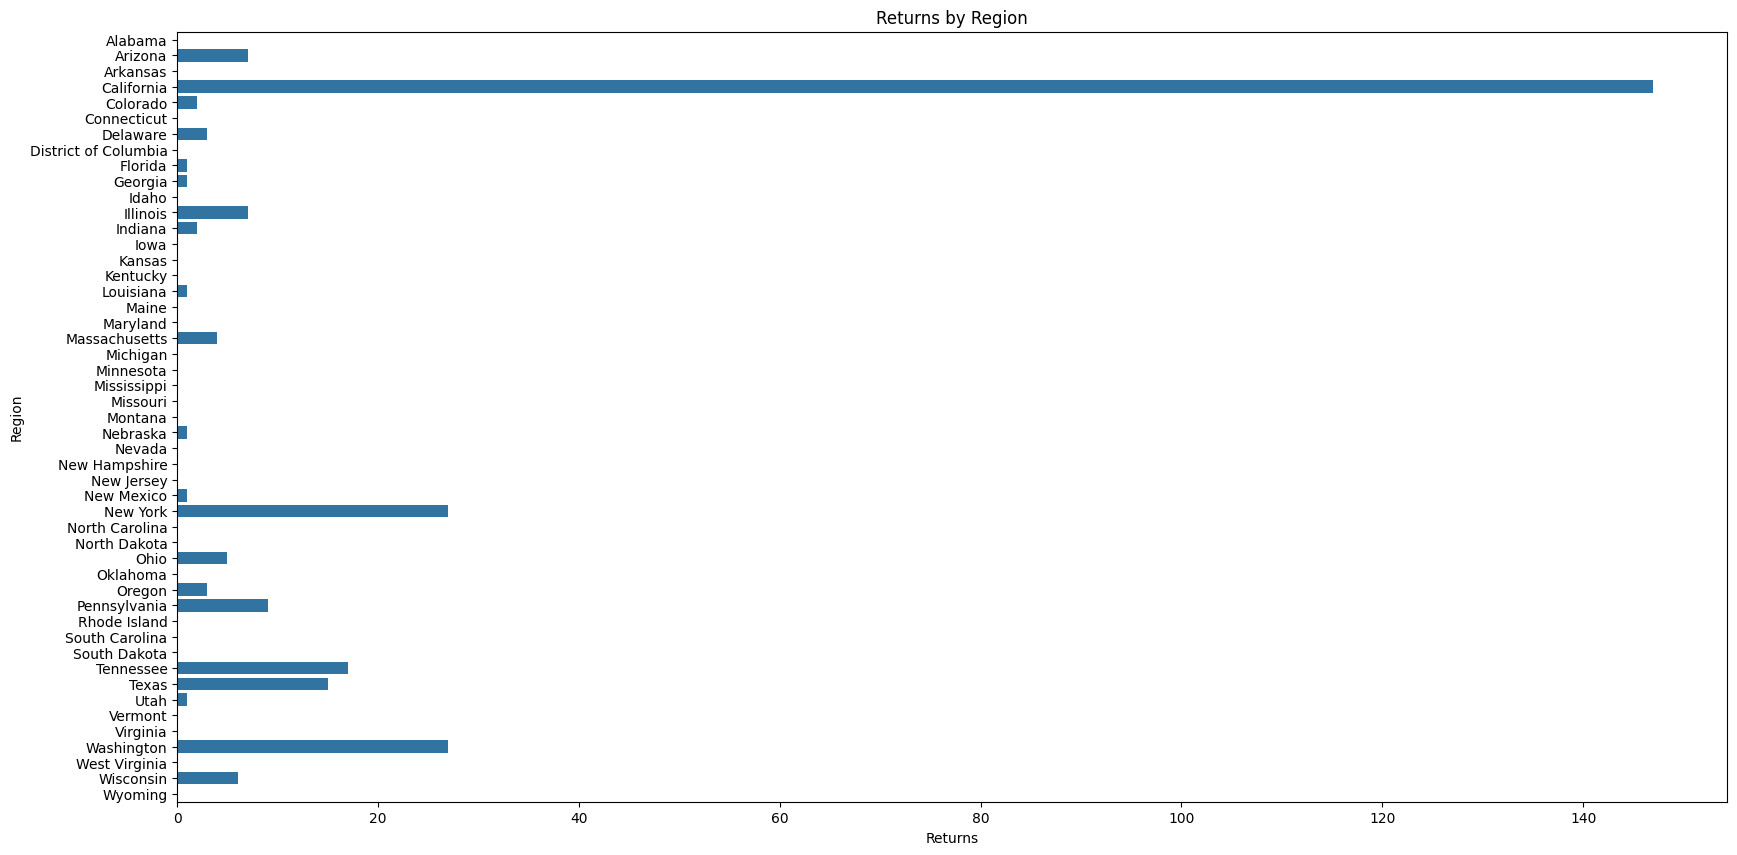

In [23]:
return_by_region = df.groupby('State')['Returns'].sum().reset_index()
plt.figure(figsize=(20,10))
sns.barplot( x='Returns', y='State', data=return_by_region ,errorbar=None)
plt.title("Returns by Region")
plt.xlabel("Returns")
plt.ylabel("Region")
plt.show()

state California has maximum returns followed by new york and washington 

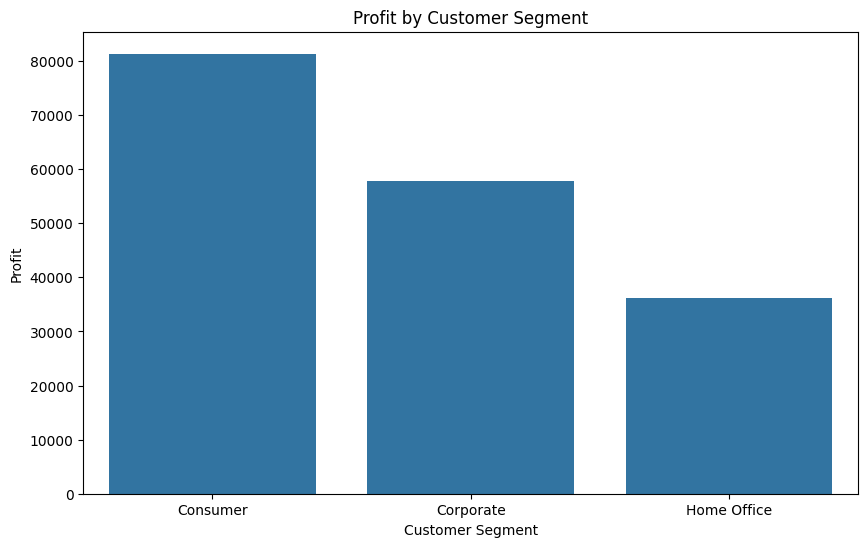

In [24]:
customer_segment = df.groupby('Segment')['Profit'].sum().reset_index()
#df['Segment'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x='Segment', y='Profit', data=customer_segment, errorbar=None)
plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit")
plt.show()



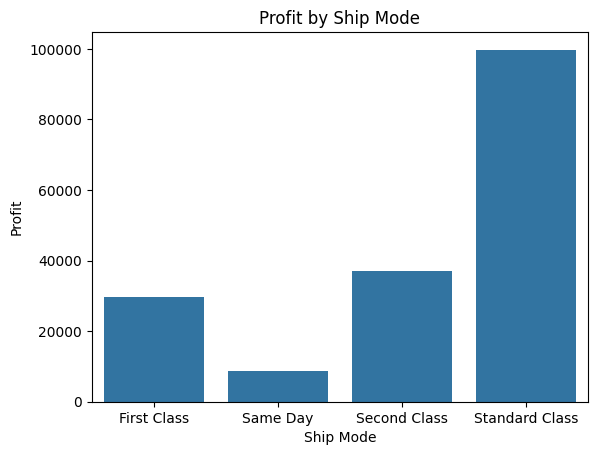

In [25]:
ship_mode_profit = df.groupby('Ship Mode')['Profit'].sum().reset_index()
df['Ship Mode'].value_counts()
sns.barplot(x='Ship Mode', y='Profit', data=ship_mode_profit, errorbar=None)
plt.title("Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Profit")
plt.show()

In [26]:
delivery_time=df['Ship Date'] - df['Order Date']
shipping_efficiency=df.groupby('Shipping Mode')

KeyError: 'Shipping Mode'

same day shipping reduces profit whereas standard shipping gives the maximum profit

In [ ]:
segment_analysis = df.groupby('Segment').agg({
    'Sales':'sum',
    'Quantity':'sum',
    'Order ID':'nunique'
})

segment_analysis['Avg_Order_Value'] = (
    segment_analysis['Sales'] / segment_analysis['Order ID']
)

segment_analysis


,Sales,Quantity,Order ID,Avg_Order_Value
Segment,,,,
Consumer,753002.1291,11199,1528,492.802441
Corporate,509743.1262,6865,915,557.096313
Home Office,303059.0679,4253,560,541.176907


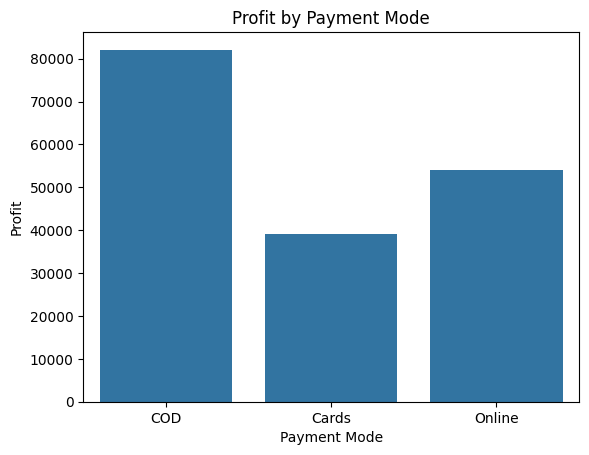

In [ ]:
payment_profit = df.groupby('Payment Mode')['Profit'].sum().reset_index()
sns.barplot(x='Payment Mode', y='Profit', data=payment_profit, errorbar=None)
plt.title("Profit by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Profit")
plt.show()

demand prediction

In [27]:
df.columns

Index(['Row_ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'valid',
       'Month', 'Year', 'rolling_mean', 'spike'],
      dtype='object')

In [28]:
monthly_demand=df.groupby(['Month','Year'])['Quantity'].sum().reset_index()
monthly_demand

,Month,Year,Quantity
0,1,2019,359
1,1,2020,597
2,2,2019,306
3,2,2020,363
4,3,2019,579
5,3,2020,885
6,4,2019,635
7,4,2020,733
8,5,2019,863
9,5,2020,887


In [33]:
monthly_demand['lag_1'] = monthly_demand['Quantity'].shift(1)
monthly_demand['lag_2'] = monthly_demand['Quantity'].shift(2)
monthly_demand['lag_3'] = monthly_demand['Quantity'].shift(3)

monthly_demand['rolling_mean_3'] = (
    monthly_demand['Quantity']
    .rolling(3)
    .mean()
)


In [34]:
monthly_demand.dropna(inplace=True)

In [35]:
from sklearn.model_selection import train_test_split
x=monthly_demand[['Month','lag_1','lag_2','lag_3','rolling_mean_3']]
y=monthly_demand['Quantity']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
                                                    random_state=42)


In [36]:
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor()
model.fit(x_train,y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
next_month = pd.DataFrame({'Month':[1], 
                           'lag_1':[1500],'lag_2':[1350],'lag_3':[1200],
                           'rolling_mean_3':[(1200+1350+1500)/3]})

In [38]:
prediction=model.predict(next_month)
print(f"Predicted demand for next month: prediction")

Predicted demand for next month: prediction
